# TFO over time

Open `log_20260422_143345.csv` and plot thermocouple `TFO_C` versus elapsed time.

In [33]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

LOG_NAME = "log_20260422_143345.csv"
TFO_COLUMN = "TFO_C"


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        csv_path = path / "data" / "raw" / "recirculation" / LOG_NAME
        if csv_path.exists():
            return path
    raise FileNotFoundError(f"Could not find data/raw/recirculation/{LOG_NAME} from {start}")


REPO_ROOT = find_repo_root()
CSV_PATH = REPO_ROOT / "data" / "raw" / "recirculation" / LOG_NAME

# The first line in this CSV is metadata, so comment="#" skips it.
df = pd.read_csv(CSV_PATH, comment="#")
df = df.sort_values("time_s").reset_index(drop=True)
# Use the logger time_s=0 reference so minutes match the CSV timestamp zero point.
df["elapsed_min"] = df["time_s"] / 60.0

display(df[["elapsed_min", "time_s", TFO_COLUMN]].head())
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print(f"Logger time: {df['elapsed_min'].min():.2f} to {df['elapsed_min'].max():.2f} min")
print(f"TFO range: {df[TFO_COLUMN].min():.2f} to {df[TFO_COLUMN].max():.2f} deg C")

,elapsed_min,time_s,TFO_C
0,263.416283,15804.977,21.231639
1,263.451000,15807.060,21.211671
2,263.485650,15809.139,21.211671
3,263.520267,15811.216,21.231639
4,263.554900,15813.294,21.231639


Loaded 11,210 rows from /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260422_143345.csv
Logger time: 263.42 to 652.03 min
TFO range: -62.05 to 21.39 deg C


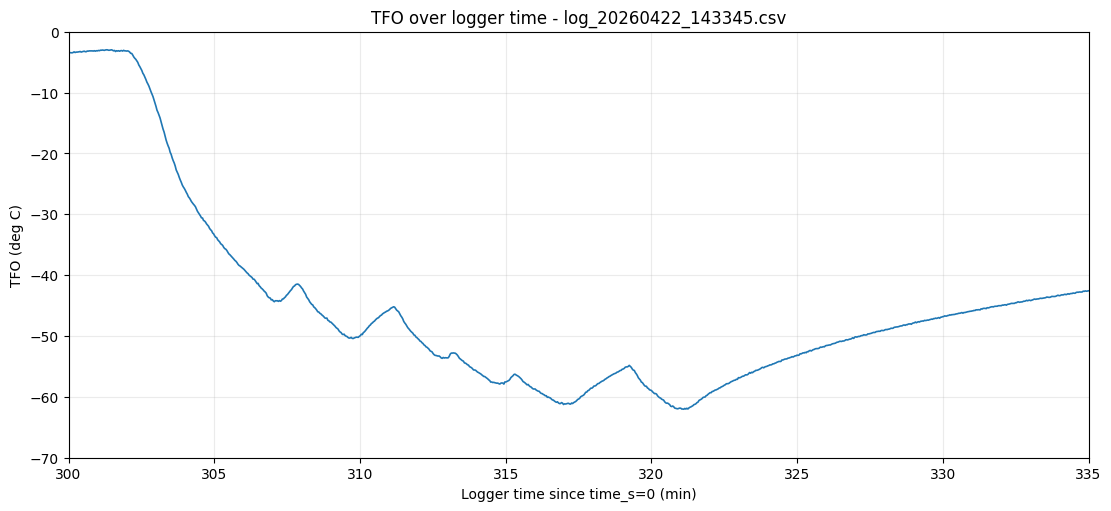

In [34]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

ax.plot(df["elapsed_min"], df[TFO_COLUMN], linewidth=1.2)
ax.set_xlabel("Logger time since time_s=0 (min)")
ax.set_ylabel("TFO (deg C)")
ax.set_ylim(-70, 0)
ax.set_xlim(300, 335)
ax.set_title("TFO over logger time - log_20260422_143345.csv")
ax.grid(True, alpha=0.25)

plt.show()

## Best-fit cooldown and warmup rates

Fit straight lines to `TFO_C` over two logger-time windows: 310-315 min for cooldown and 325-330 min for warmup. The fitted slope is the rate in deg C/min.

In [35]:
import numpy as np

COOLDOWN_WINDOW_MIN = (310.0, 315.0)
WARMUP_WINDOW_MIN = (325.0, 330.0)


def fit_temperature_window(frame, window_min, y_column=TFO_COLUMN):
    start_min, end_min = window_min
    fit_data = frame.loc[frame["elapsed_min"].between(start_min, end_min)].copy()
    if len(fit_data) < 2:
        raise ValueError(f"Not enough samples in {start_min:g}-{end_min:g} min")

    x = fit_data["elapsed_min"].to_numpy(float)
    y = pd.to_numeric(fit_data[y_column], errors="coerce").to_numpy(float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 2:
        raise ValueError(f"Not enough finite samples in {start_min:g}-{end_min:g} min")

    slope, intercept = np.polyfit(x, y, deg=1)
    fitted = slope * x + intercept
    residual = y - fitted
    ss_res = float(np.sum(residual**2))
    ss_tot = float(np.sum((y - float(np.mean(y))) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan

    return fit_data, {
        "window_min": f"{start_min:g}-{end_min:g}",
        "start_min": start_min,
        "end_min": end_min,
        "n_samples": int(len(x)),
        "slope_degC_per_min": float(slope),
        "intercept_degC": float(intercept),
        "r_squared": float(r_squared),
        "temperature_start_fit_degC": float(slope * start_min + intercept),
        "temperature_end_fit_degC": float(slope * end_min + intercept),
    }


cooldown_fit_data, cooldown_fit = fit_temperature_window(df, COOLDOWN_WINDOW_MIN)
warmup_fit_data, warmup_fit = fit_temperature_window(df, WARMUP_WINDOW_MIN)
fit_summary = pd.DataFrame([
    {"phase": "cooldown", **cooldown_fit},
    {"phase": "warmup", **warmup_fit},
])

display(fit_summary[["phase", "window_min", "n_samples", "slope_degC_per_min", "r_squared", "temperature_start_fit_degC", "temperature_end_fit_degC"]])
cooldown_rate_degC_per_min = cooldown_fit["slope_degC_per_min"]
warmup_rate_degC_per_min = warmup_fit["slope_degC_per_min"]
print(f"Cooldown rate: {cooldown_rate_degC_per_min:.3f} deg C/min")
print(f"Warmup rate: {warmup_rate_degC_per_min:.3f} deg C/min")

,phase,window_min,n_samples,slope_degC_per_min,r_squared,temperature_start_fit_degC,temperature_end_fit_degC
0,cooldown,310-315,144,-2.531940,0.868157,-45.486313,-58.146012
1,warmup,325-330,144,1.247892,0.994904,-52.871016,-46.631555


Cooldown rate: -2.532 deg C/min
Warmup rate: 1.248 deg C/min


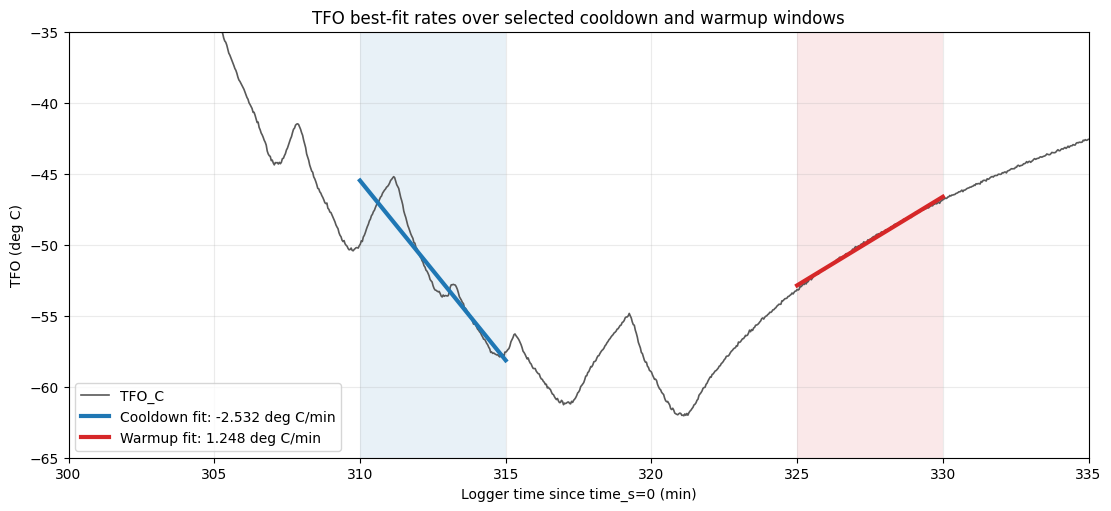

In [36]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

plot_window = df["elapsed_min"].between(300.0, 335.0)
ax.plot(df.loc[plot_window, "elapsed_min"], df.loc[plot_window, TFO_COLUMN], linewidth=1.2, color="0.35", label="TFO_C")

for label, fit, color in [
    ("Cooldown fit", cooldown_fit, "C0"),
    ("Warmup fit", warmup_fit, "C3"),
]:
    x_line = np.linspace(fit["start_min"], fit["end_min"], 100)
    y_line = fit["slope_degC_per_min"] * x_line + fit["intercept_degC"]
    rate = fit["slope_degC_per_min"]
    ax.plot(x_line, y_line, linewidth=3.0, color=color, label=f"{label}: {rate:.3f} deg C/min")
    ax.axvspan(fit["start_min"], fit["end_min"], color=color, alpha=0.10, linewidth=0)

ax.set_xlabel("Logger time since time_s=0 (min)")
ax.set_ylabel("TFO (deg C)")
ax.set_title("TFO best-fit rates over selected cooldown and warmup windows")
ax.set_xlim(300, 335)
ax.set_ylim(-65, -35)
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.show()